<a href="https://colab.research.google.com/github/Kotyga/ML_toolkit/blob/main/%D0%90%D0%BD%D0%B0%D0%BB%D0%B8%D0%B7_%D0%BA%D0%BE%D1%80%D1%80%D0%B5%D0%BB%D1%8F%D1%86%D0%B8%D0%B9_%D1%87%D0%B5%D1%80%D0%B5%D0%B7_%D0%B3%D1%80%D0%B0%D1%84%D1%8B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from datetime import timedelta
from time import perf_counter

import matplotlib.pyplot as plt
import plotly.express as px
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split

In [2]:
seed = 42
np.random.seed(seed)

# Работа с датасетом

In [3]:
def build_dataset(rnd=42, base_feats=7, n_inform=5, n_redund=2, n_samples=1000):

    X, y = make_classification(
        n_samples=n_samples,
        n_features=base_feats,
        n_informative=n_inform,
        n_redundant=n_redund,
        n_repeated=0,
        class_sep=1.0,
        shuffle=False,
        random_state=rnd
    )

    orig_cols = [f"orig_{i+1}" for i in range(base_feats)] # сначала информативные, потом ЛК, потом повторы, потом шум
    df = pd.DataFrame(X, columns=orig_cols)
    df["target"] = y
    return df

In [4]:
data = build_dataset(rnd=seed,
                   base_feats=8,
                   n_inform=5,
                   n_redund=2,
                   n_samples=1000)

В данном кейсе
* orig_(1-5) - информативные фичи
* orig_(6-7) - линейная комбинация фич
* orig_8     - шумная фича

Посмотрим, как определит "лучшие" признаки алгоритм на базе поиска клик


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   orig_1  1000 non-null   float64
 1   orig_2  1000 non-null   float64
 2   orig_3  1000 non-null   float64
 3   orig_4  1000 non-null   float64
 4   orig_5  1000 non-null   float64
 5   orig_6  1000 non-null   float64
 6   orig_7  1000 non-null   float64
 7   orig_8  1000 non-null   float64
 8   target  1000 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 70.4 KB


In [6]:
print("Распределение классов, %:")
data["target"].value_counts(normalize=True) * 100

Распределение классов, %:


,proportion
target,
1,50.2
0,49.8


# Оценка корреляции

In [7]:
features = data.drop(columns=["target"])
corr = features.corr(method="pearson")

corr_mat = corr.stack().reset_index(name="correlation")
corr_mat.rename(columns={"level_0": "var1", "level_1": "var2"}, inplace=True)

corr_mat["abs_corr"] = corr_mat["correlation"].abs()

In [8]:
fig = px.scatter(corr_mat, x="var1", y="var2", color="correlation", size="abs_corr",
    color_continuous_scale="RdBu", range_color=[-1, 1], color_continuous_midpoint=0,
    size_max=18, width=450, height=450, hover_data={"correlation": ":.3f", "abs_corr": False})

fig.update_layout(
    xaxis=dict(tickangle=90),
    yaxis=dict(tickangle=0),
    xaxis_title="",
    yaxis_title="",
    showlegend=False
)

fig.show()

# Отображение корреляции для github

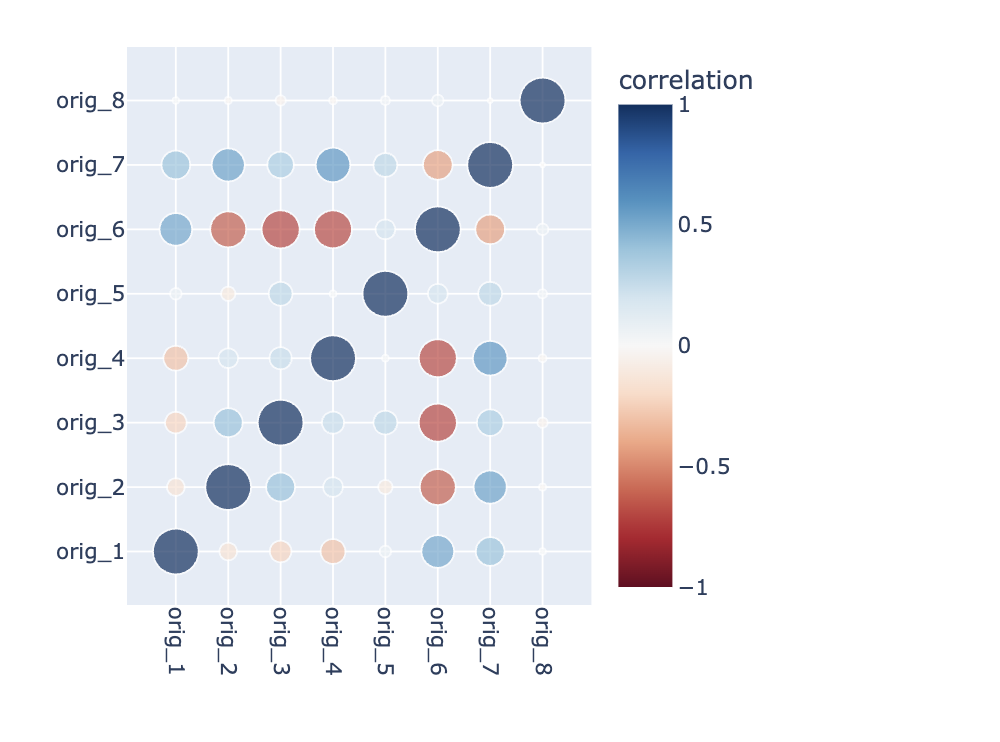

# Оценка распределения

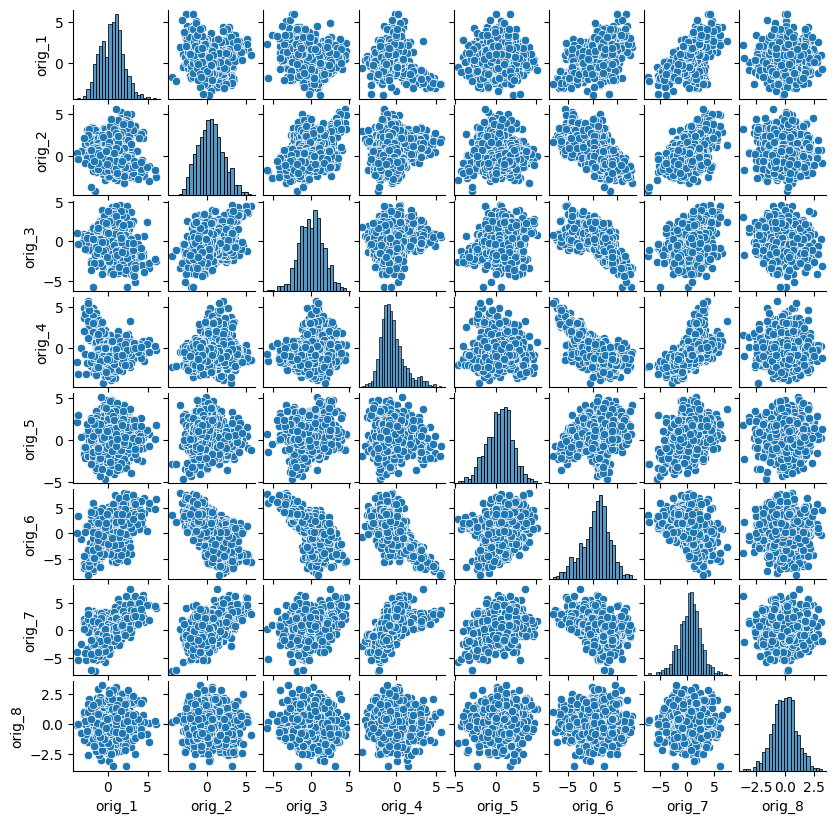

In [9]:
pp = sns.pairplot(data.drop(columns=["target"]))
pp.fig.set_size_inches(8, 8)

# Анализ влияния фич на скор

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop(columns=['target']).copy(), data['target'],
    test_size=0.2,
    stratify=data['target'],
    shuffle=True,
    random_state=seed
)

In [11]:
train_df = X_train.copy()
train_df['y'] = y_train.values

In [12]:
def fit_report_logit(spec, use_l1, train_frame, holdout_frame, holdout_labels,
                     threshold=0.5, suppress_warnings=True):
    if use_l1:
        mdl = smf.logit(formula=spec, data=train_frame).fit_regularized(method='l1')
    else:
        mdl = smf.logit(formula=spec, data=train_frame).fit(method='lbfgs', disp=False)

    print(mdl.summary2())

    probs = np.asarray(mdl.predict(holdout_frame)).ravel()
    preds = (probs > threshold).astype(int)

    auc_val = roc_auc_score(holdout_labels, probs)
    f1_val = f1_score(holdout_labels, preds)

    print("ROC AUC (test): {:.6f}".format(auc_val))
    print("F1 score (test): {:.6f}".format(f1_val))

    return {"model": mdl, "probs": probs, "preds": preds, "auc": auc_val, "f1": f1_val}

Обратим внимание на следующие случаи:

1. Коэффициент у признака меняет знак.
2. Доверительные интервалы расширяются.
3. Абсолютное значение коэффициента может значительно изменяться.

In [13]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=False, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    y                  Pseudo R-squared:   0.371     
Date:                  2025-08-11 17:09   AIC:                711.4347  
No. Observations:      800                BIC:                744.2270  
Df Model:              6                  Log-Likelihood:     -348.72   
Df Residuals:          793                LL-Null:            -554.51   
Converged:             1.0000             LLR p-value:        9.0450e-86
No. Iterations:        11.0000            Scale:              1.0000    
------------------------------------------------------------------------
           Coef.    Std.Err.      z    P>|z|      [0.025       0.975]   
------------------------------------------------------------------------
Intercept  0.7713       0.1211  6.3690 0.0000        0.5340       1.0087
orig_1    -0.6431 1759283.8343 -0.0000 1.0000 -3448133.5969 3448132.3108
orig_2 

In [14]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
    + orig_6
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=True, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4358966868564482
            Iterations: 24
            Function evaluations: 24
            Gradient evaluations: 24
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.371     
Date:               2025-08-11 17:09 AIC:              715.4347  
No. Observations:   800              BIC:              757.5962  
Df Model:           8                Log-Likelihood:   -348.72   
Df Residuals:       791              LL-Null:          -554.51   
Converged:          1.0000           LLR p-value:      6.2350e-84
No. Iterations:     24.0000          Scale:            1.0000    
-------------------------------------------------------------------
             Coef.    Std.Err.     z      P>|z|     [0.025   0.975]
-------------------------------------------------------------------
Intercept    0.771

In [15]:
spec = """
    y ~
    + orig_1
    + orig_5
    + orig_6
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=False, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.182     
Date:               2025-08-11 17:09 AIC:              919.1490  
No. Observations:   800              BIC:              947.2567  
Df Model:           5                Log-Likelihood:   -453.57   
Df Residuals:       794              LL-Null:          -554.51   
Converged:          1.0000           LLR p-value:      1.1327e-41
No. Iterations:     12.0000          Scale:            1.0000    
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept      0.0110    0.0873   0.1255  0.9001  -0.1601   0.1820
orig_1        -1.0874    0.1437  -7.5667  0.0000  -1.3690  -0.8057
orig_5         0.3107    0.0772   4.0240  0.0001   0.1594   0.4620
orig_6         0.3130    0.078

In [16]:
spec = """
    y ~
    + orig_1
    + orig_5
    + orig_6
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=True, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.566968122866647
            Iterations: 21
            Function evaluations: 21
            Gradient evaluations: 21
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.182     
Date:               2025-08-11 17:09 AIC:              919.1490  
No. Observations:   800              BIC:              947.2567  
Df Model:           5                Log-Likelihood:   -453.57   
Df Residuals:       794              LL-Null:          -554.51   
Converged:          1.0000           LLR p-value:      1.1327e-41
No. Iterations:     21.0000          Scale:            1.0000    
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept      0.0110 

In [17]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=False, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    y                  Pseudo R-squared:   0.371     
Date:                  2025-08-11 17:09   AIC:                711.4347  
No. Observations:      800                BIC:                744.2270  
Df Model:              6                  Log-Likelihood:     -348.72   
Df Residuals:          793                LL-Null:            -554.51   
Converged:             1.0000             LLR p-value:        9.0450e-86
No. Iterations:        11.0000            Scale:              1.0000    
------------------------------------------------------------------------
           Coef.    Std.Err.      z    P>|z|      [0.025       0.975]   
------------------------------------------------------------------------
Intercept  0.7713       0.1211  6.3690 0.0000        0.5340       1.0087
orig_1    -0.6431 1759283.8343 -0.0000 1.0000 -3448133.5969 3448132.3108
orig_2 

In [18]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=True, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4358966868564864
            Iterations: 27
            Function evaluations: 27
            Gradient evaluations: 27
                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    y                  Pseudo R-squared:   0.371     
Date:                  2025-08-11 17:09   AIC:                713.4347  
No. Observations:      800                BIC:                750.9116  
Df Model:              7                  Log-Likelihood:     -348.72   
Df Residuals:          792                LL-Null:            -554.51   
Converged:             1.0000             LLR p-value:        7.8277e-85
No. Iterations:        27.0000            Scale:              1.0000    
------------------------------------------------------------------------
           Coef.    Std.Err.      z    P>|z|      [0.025       0.975]   
----------------

In [19]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
"""
fit_report_logit(spec, use_l1=False, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.371     
Date:               2025-08-11 17:09 AIC:              709.8309  
No. Observations:   800              BIC:              737.9386  
Df Model:           5                Log-Likelihood:   -348.92   
Df Residuals:       794              LL-Null:          -554.51   
Converged:          1.0000           LLR p-value:      1.1520e-86
No. Iterations:     11.0000          Scale:            1.0000    
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept      0.7687    0.1209   6.3595  0.0000   0.5318   1.0056
orig_1        -0.7174    0.0758  -9.4646  0.0000  -0.8660  -0.5689
orig_2        -0.7305    0.0823  -8.8759  0.0000  -0.8918  -0.5692
orig_3        -0.2303    0.074

In [20]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
"""
fit_report_logit(spec, use_l1=True, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.43614433349792364
            Iterations: 23
            Function evaluations: 23
            Gradient evaluations: 23
                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.371     
Date:               2025-08-11 17:09 AIC:              709.8309  
No. Observations:   800              BIC:              737.9386  
Df Model:           5                Log-Likelihood:   -348.92   
Df Residuals:       794              LL-Null:          -554.51   
Converged:          1.0000           LLR p-value:      1.1520e-86
No. Iterations:     23.0000          Scale:            1.0000    
------------------------------------------------------------------
               Coef.   Std.Err.     z     P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept      0.768

# Поиск клики

In [21]:
def feature_mutual_info(frame, labels, random_seed=seed, n_neighbors=5):

    scores = dict()

    for feature in frame.columns:
        mask = ~frame[feature].isna()
        X = frame[mask][[feature]]
        y = labels[mask]
        discr_fts_mask = X.dtypes.values == 'int64'

        score = mutual_info_classif(
            X=X,
            y=y,
            discrete_features=discr_fts_mask,
            n_neighbors=n_neighbors,
            random_state=random_seed
        )
        scores[feature] = score[0]

    return scores


In [22]:
def _bit_iter(mask):
    while mask:
        lsb = mask & -mask
        v = lsb.bit_length() - 1
        yield v
        mask &= mask - 1

def _bron_kerbosch_pivot_all_cliques(neighbors, n):

    full = (1 << n) - 1

    def rec(R, P, X):
        if P == 0 and X == 0:
            yield R
            return
        union_PX = P | X
        max_u = None
        max_count = -1
        tmp = union_PX
        while tmp:
            u = (tmp & -tmp).bit_length() - 1
            tmp &= tmp - 1
            cnt = bin(P & neighbors[u]).count("1")
            if cnt > max_count:
                max_count = cnt
                max_u = u
        if max_u is None:
            candidates = P
        else:
            candidates = P & ~neighbors[max_u]
        tmp = candidates
        while tmp:
            v = (tmp & -tmp).bit_length() - 1
            tmp &= tmp - 1
            v_bit = 1 << v
            yield from rec(R | v_bit, P & neighbors[v], X & neighbors[v])
            P &= ~v_bit
            X |= v_bit

    yield from rec(0, full, 0)


def get_noncollinear_fts(dataset, target, trsh=0.8, mode="all", random_seed=1234, verbose=True):

    t0 = perf_counter()

    if verbose:
        print(f"=> mutual info calculation...")
    t1 = perf_counter()
    scores = feature_mutual_info(dataset, target, random_seed)
    if isinstance(scores, (pd.Series, pd.DataFrame)):
        scores = scores.to_dict()
    if verbose:
        print(f"Task completed in: {timedelta(seconds=(perf_counter()-t1))}\n")

    if verbose:
        print(f"=> corr_matrix calculation...")
    t1 = perf_counter()
    corr_matrix = dataset.corr().abs()
    fts = list(corr_matrix.columns)
    corr_matrix = np.array(corr_matrix)
    if verbose:
        print(f"Task completed in: {timedelta(seconds=(perf_counter()-t1))}\n")

    if verbose:
        print(f"=> graph assembling...")
    t1 = perf_counter()
    np.fill_diagonal(corr_matrix, 2)
    corr_df = pd.DataFrame(corr_matrix, columns=fts, index=fts)
    graph_matrix = corr_df[abs(corr_df) > trsh]
    graph_matrix[~graph_matrix.isna()] = 0
    graph_matrix.fillna(1, inplace=True)

    G = nx.DiGraph(np.array(graph_matrix))
    G = nx.relabel_nodes(G, dict(zip(list(G.nodes), fts)))
    if verbose:
        print(f"Task completed in: {timedelta(seconds=(perf_counter()-t1))}\n")

    if verbose:
        print(f"=> cliques (Tomita/Bron-Kerbosch pivot) search...")
    t1 = perf_counter()

    n = len(fts)
    neighbors = [0] * n
    gm = np.array(graph_matrix, dtype=int)
    gm = np.maximum(gm, gm.T)
    for i in range(n):
        row = gm[i]
        mask = 0
        for j, val in enumerate(row):
            if val:
                mask |= 1 << j
        neighbors[i] = mask

    cliques_bits = list(_bron_kerbosch_pivot_all_cliques(neighbors, n))

    cliques = []
    for b in cliques_bits:
        clique_idxs = list(_bit_iter(b))
        cliques.append([fts[i] for i in clique_idxs])

    if verbose:
        print(f"{len(cliques)} maximal cliques are found:\n")
    lens = np.array(list(map(len, cliques)))
    stat = pd.Series(lens).value_counts().sort_index()
    if verbose:
        print(stat)
    if verbose:
        print(f"Task completed in: {timedelta(seconds=(perf_counter()-t1))}\n")

    if verbose:
        print(f"=> best cliques search...")
    t1 = perf_counter()
    answer = {}
    if len(stat) == 0:
        if verbose:
            print("No cliques found.")
        print(f"All tasks completed in: {timedelta(seconds=(perf_counter()-t0))}")
        return answer, G

    if mode == "all":
        iter_list = sorted(np.array(stat.index))
    elif mode == "max":
        iter_list = [int(np.array(stat.index).max())]
    else:
        raise ValueError("mode must be 'all' or 'max'")

    for val in iter_list:
        if verbose:
            print(f"Search best clique for dim = {val}")
        max_curr = -1e100
        fts_list = []

        for idx in np.argwhere(lens == val).ravel():
            summa = 0.0
            for col in cliques[idx]:
                summa += float(scores.get(col, 0.0))
            if summa > max_curr:
                max_curr = summa
                fts_list = cliques[idx]
        answer[val] = (fts_list, max_curr)
    if verbose:
        print(f"Task completed in: {timedelta(seconds=(perf_counter()-t1))}\n")
    print(f"All tasks completed in: {timedelta(seconds=(perf_counter()-t0))}")

    return answer, G

In [23]:
qlq_list, G = get_noncollinear_fts(
    data.drop(columns=["target"]), data['target'], trsh=0.65, mode="all", verbose=True)

=> mutual info calculation...
Task completed in: 0:00:00.094876

=> corr_matrix calculation...
Task completed in: 0:00:00.001324

=> graph assembling...
Task completed in: 0:00:00.004148

=> cliques (Tomita/Bron-Kerbosch pivot) search...
2 maximal cliques are found:

6    1
7    1
Name: count, dtype: int64
Task completed in: 0:00:00.004052

=> best cliques search...
Search best clique for dim = 6
Search best clique for dim = 7
Task completed in: 0:00:00.000111

All tasks completed in: 0:00:00.104891


In [24]:
qlq_list

{np.int64(6): (['orig_1', 'orig_2', 'orig_5', 'orig_6', 'orig_7', 'orig_8'],
  0.4427203684425147),
 np.int64(7): (['orig_1',
   'orig_2',
   'orig_3',
   'orig_4',
   'orig_5',
   'orig_7',
   'orig_8'],
  0.39182035325308506)}

# Проанализируем скор по фичам, найденным по графу

In [25]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_5
    + orig_6
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=False, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: y                Pseudo R-squared: 0.371     
Date:               2025-08-11 17:09 AIC:              711.4347  
No. Observations:   800              BIC:              744.2270  
Df Model:           6                Log-Likelihood:   -348.72   
Df Residuals:       793              LL-Null:          -554.51   
Converged:          1.0000           LLR p-value:      9.0450e-86
No. Iterations:     18.0000          Scale:            1.0000    
------------------------------------------------------------------
              Coef.   Std.Err.     z      P>|z|    [0.025   0.975]
------------------------------------------------------------------
Intercept     0.7714    0.1211    6.3691  0.0000   0.5340   1.0087
orig_1       -1.9962    0.1942  -10.2799  0.0000  -2.3768  -1.6156
orig_2       -1.3535    0.1164  -11.6286  0.0000  -1.5816  -1.1254
orig_5       -0.0344    0.0919

In [26]:
spec = """
    y ~
    + orig_1
    + orig_2
    + orig_3
    + orig_4
    + orig_5
    + orig_7
    + orig_8
"""
fit_report_logit(spec, use_l1=True, train_frame=train_df, holdout_frame=X_test, holdout_labels=y_test);

Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.4358966868564864
            Iterations: 27
            Function evaluations: 27
            Gradient evaluations: 27
                             Results: Logit
Model:                 Logit              Method:             MLE       
Dependent Variable:    y                  Pseudo R-squared:   0.371     
Date:                  2025-08-11 17:09   AIC:                713.4347  
No. Observations:      800                BIC:                750.9116  
Df Model:              7                  Log-Likelihood:     -348.72   
Df Residuals:          792                LL-Null:            -554.51   
Converged:             1.0000             LLR p-value:        7.8277e-85
No. Iterations:        27.0000            Scale:              1.0000    
------------------------------------------------------------------------
           Coef.    Std.Err.      z    P>|z|      [0.025       0.975]   
----------------

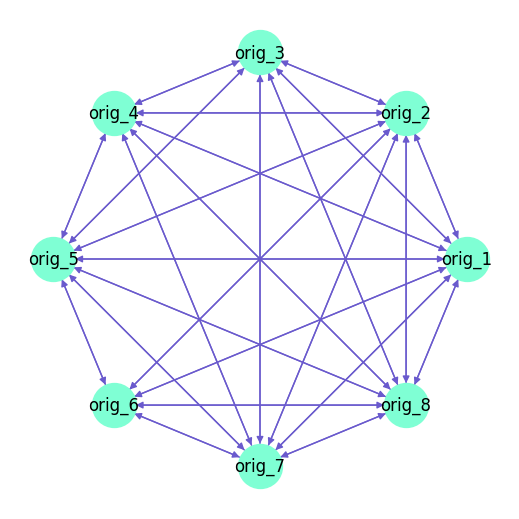

In [27]:
plt.figure(figsize=(5, 5))
nx.draw_circular(G, with_labels=1, node_color='#7fffd4',
                 edge_color='#6a5acd', node_size=1000)